# Feature Scaling vs Feature Transformation

## 1. What is Feature Scaling?

### Definition

Feature scaling changes the scale (magnitude/range) of features without changing their distribution shape.

**Key Question:** "Are my features comparable in size?"

### Example

**Before Scaling:**

| Feature | Original Range |
|---------|----------------|
| Age | 18–60 |
| Salary | ₹20,000–₹2,00,000 |

**Problem:** Salary dominates distance & gradients ❌

**After Scaling:**

| Feature | New Range |
|---------|-----------|
| Age | ~(-1 to 1) |
| Salary | ~(-1 to 1) |

**Result:** Now both matter equally ✅

### What Problem Does Feature Scaling Solve?

- Prevents large-valued features from dominating
- Improves numerical stability
- Speeds up gradient descent
- Makes distance meaningful

### Types of Feature Scaling

1. Standardization (Z-score)
2. Normalization (Min–Max)
3. RobustScaler
4. MaxAbsScaler
5. L2 Normalization

### What Feature Scaling Does NOT Do

- ❌ Does not fix skewness
- ❌ Does not make data normal
- ❌ Does not handle non-linearity

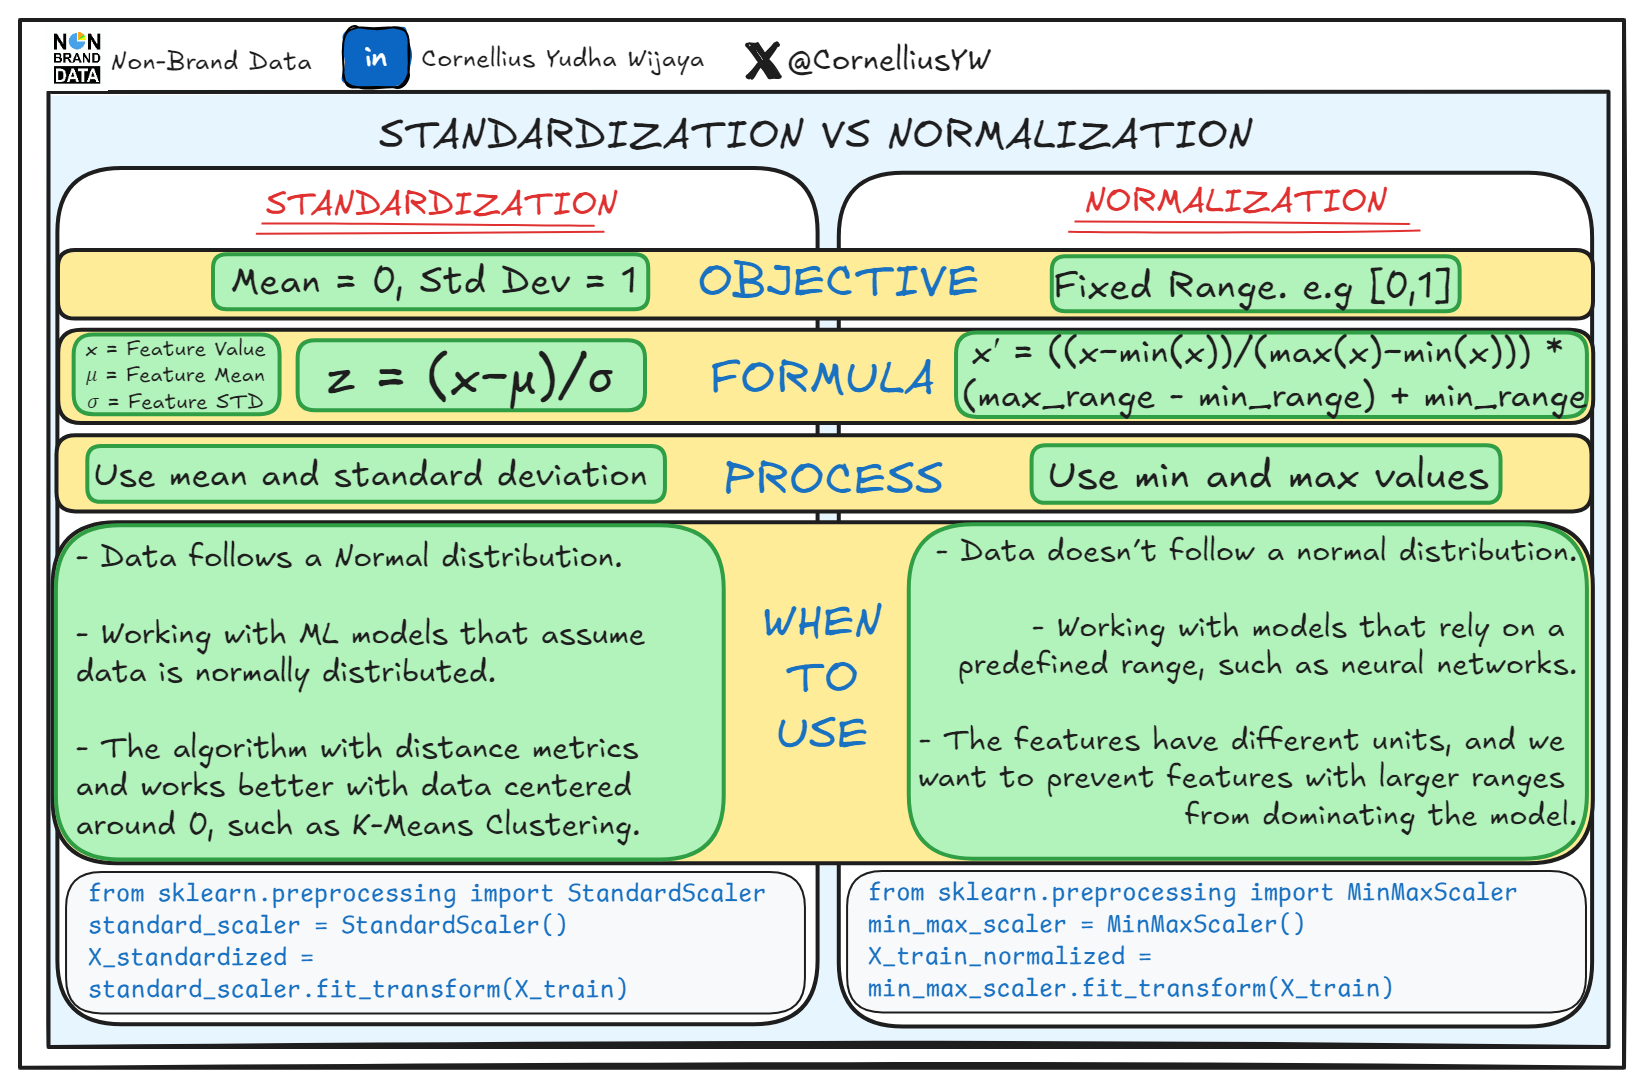             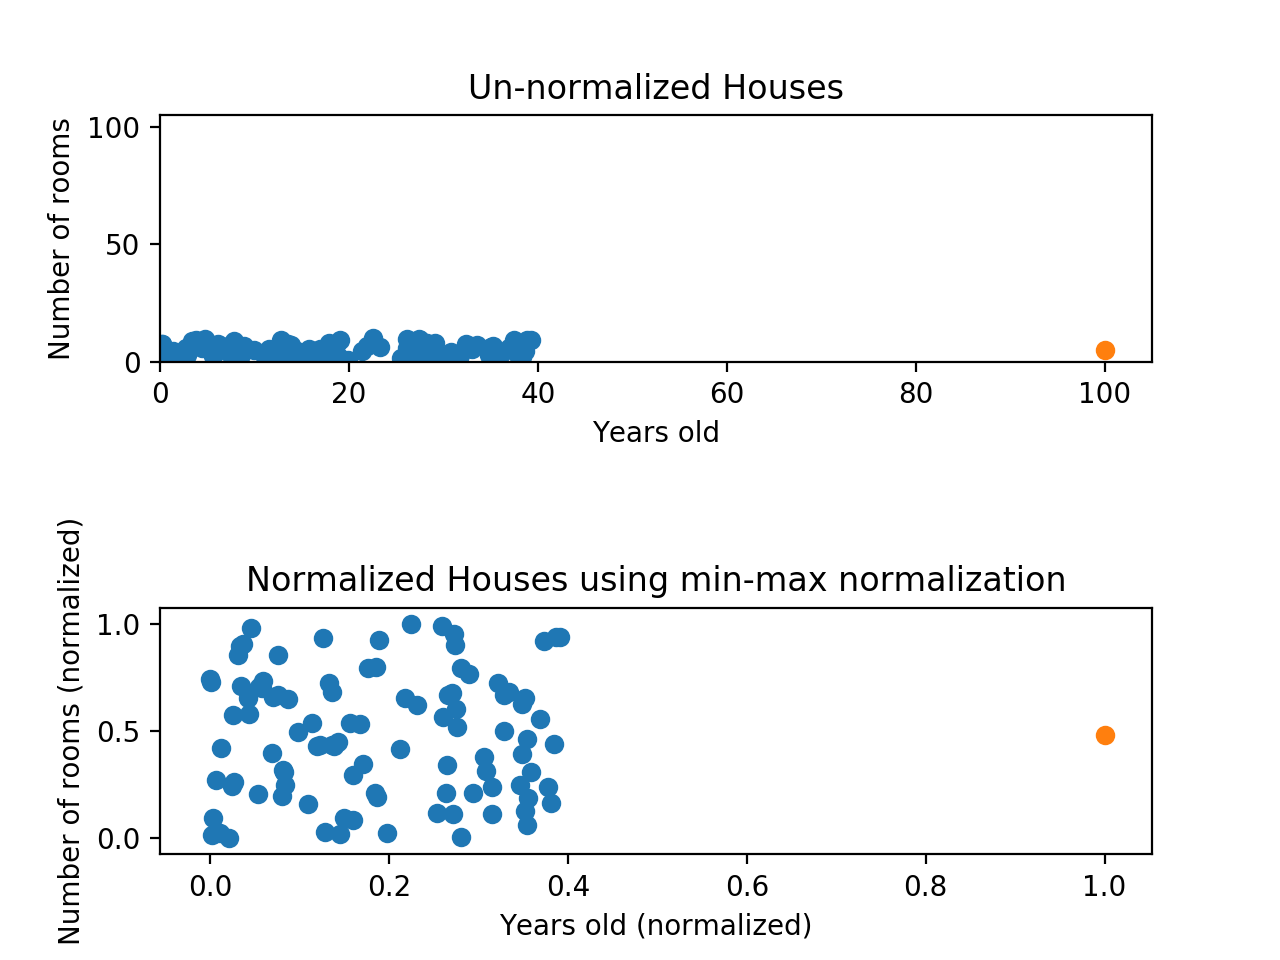
---


## 2. What is Feature Transformation?

### Definition

Feature transformation changes the shape or distribution of data using a mathematical function.

**Key Question:** "Is my data well-behaved for this algorithm?"

### Example (Right-Skewed Data)

Income/Fare/Sales data:
Original: |■■■■■■■■■■■■■■■
After log: |■■■■■■■■■■■■


**Result:** Distribution becomes more symmetric ✅

### What Problem Does Feature Transformation Solve?

- Fixes skewed distributions
- Stabilizes variance
- Makes relationships more linear
- Helps meet model assumptions

### Types of Feature Transformation

1. Log transformation
2. Square root
3. Reciprocal
4. Box-Cox
5. Yeo-Johnson
6. Polynomial features

### What Feature Transformation Does NOT Do

- ❌ Does not equalize feature scales
- ❌ Does not make features comparable

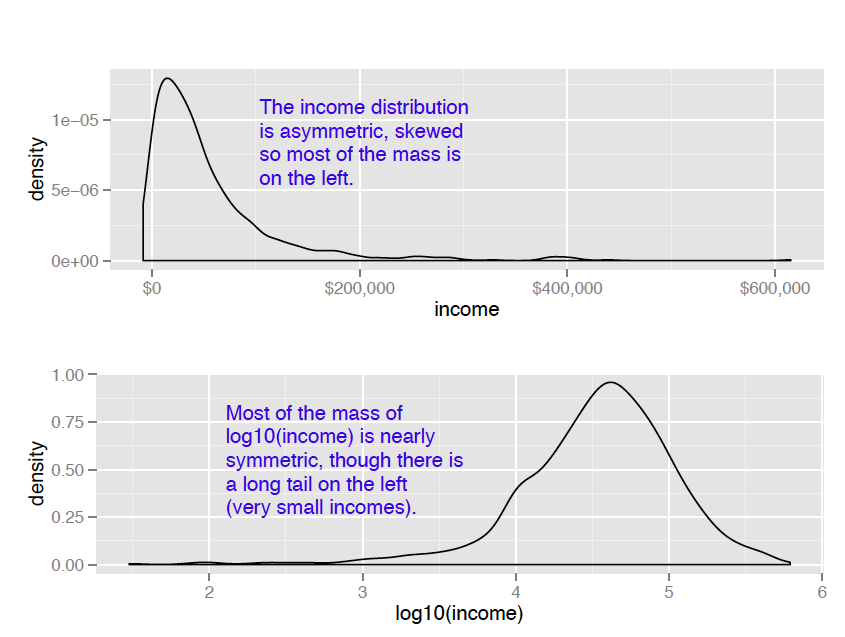           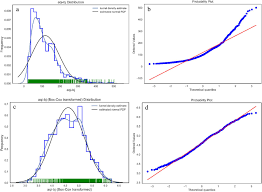


---

## 3. Core Difference: Feature Scaling vs Feature Transformation

| Aspect | Feature Scaling | Feature Transformation |
|--------|-----------------|------------------------|
| **Changes magnitude** | ✅ | ❌ |
| **Changes shape** | ❌ | ✅ |
| **Fixes skewness** | ❌ | ✅ |
| **Improves gradients** | ✅ | ❌ |
| **Makes features comparable** | ✅ | ❌ |
| **Mathematical nature** | Linear | Non-linear |

### One-Line Intuition (Very Important)

> **Scaling** fixes HOW BIG the numbers are.
> 
> **Transformation** fixes HOW the data is distributed.

---

## 4. Why Do We Have Both?

Because they solve **different problems**.

### Problem 1: Different Units
- **Example:** Age vs Salary
- **Solution:** Feature Scaling ✔

### Problem 2: Skewed/Non-Normal Data
- **Example:** Income, Fare, Population
- **Solution:** Feature Transformation ✔

---

## 5. Real-World Pipeline
Raw Data
↓
Feature Transformation (log/power)
↓
Feature Scaling (standardization)
↓
Model Training


### How This Helps ML Algorithms

#### Gradient-Based Algorithms
- Linear Regression
- Logistic Regression
- Neural Networks

**Benefits:**
- ✔ Faster convergence
- ✔ Stable optimization

#### Distance-Based Algorithms
- KNN
- SVM
- K-means

**Benefits:**
- ✔ Fair distance calculation

#### Statistical Models
- Linear Regression assumptions
- PCA

**Benefits:**
- ✔ Better variance explanation
- ✔ More meaningful components

---

## 6. When to Use Feature Scaling

### Use Scaling When:

- Features have different units
- Algorithm uses distance or gradients

### Algorithms That NEED Scaling

| Algorithm | Scaling Required |
|-----------|------------------|
| Linear Regression | ✅ |
| Logistic Regression | ✅ |
| SVM | ✅ |
| KNN | ✅ |
| PCA | ✅ |
| Neural Networks | ✅ |

### Algorithms That DON'T Need Scaling

- Decision Tree
- Random Forest
- XGBoost

---

## 7. When to Use Feature Transformation

### Use Transformation When:

- Data is skewed
- Variance increases with magnitude
- Relationship is non-linear

### Common Cases Requiring Transformation

- Income
- Fare
- Sales
- Population
- Time-based growth

---

## 8. When to Use BOTH Together

**Yes** — very often you use both in practice.

**Example:**
Log transform → Standardize → Logistic Regression


---

## 9. Interview-Ready Final Answer

> Feature scaling and feature transformation are preprocessing techniques that solve different problems. Feature scaling adjusts the magnitude of features to make them comparable and improve optimization, while feature transformation modifies the distribution shape to reduce skewness, stabilize variance, and satisfy model assumptions. Scaling is mainly required for distance- and gradient-based algorithms, whereas transformation is used when data is skewed or non-linear. In practice, transformation is often applied first, followed by scaling.

---

## Mental Checklist

Use this every time you preprocess data:

- ❓ Are features on different scales? → **Scale**
- ❓ Is data skewed or non-normal? → **Transform**
- ❓ Using tree models? → **Skip both**
- ❓ Using linear/distance/NN models? → **Use both**

# Function Transformation

## Overview
Function transformation involves applying mathematical functions to data to make it easier for models and algorithms to understand and learn. It helps reduce skewness and make relationships more linear.

## Four Types of Transformations

1. **Log Transformation** - `np.log1p()`
2. **Reciprocal Transformation** - `1/x`
3. **Square/Square Root Transformation** - `√x` or `x²`
4. **Custom Transformation** - Any custom function you define

## Why Is Transformation Needed?

When comparing features with different scales, larger-scaled features dominate the model.

### Example

Consider these two features:
- **Height**: 150–190 cm
- **Salary**: ₹20,000–₹2,00,000

If compared directly, salary dominates due to its larger scale. Transformation puts them on a fair, comparable scale.

- **QQPlot and Dist plot is used to Check if there is any skrewness/ Transformation is needed or not**

- **This changes the shape of the dataset**

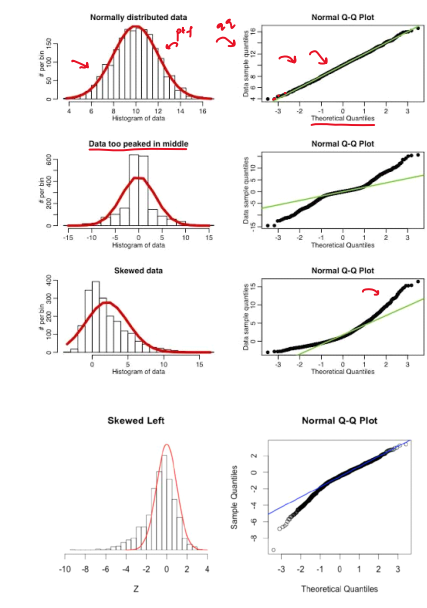      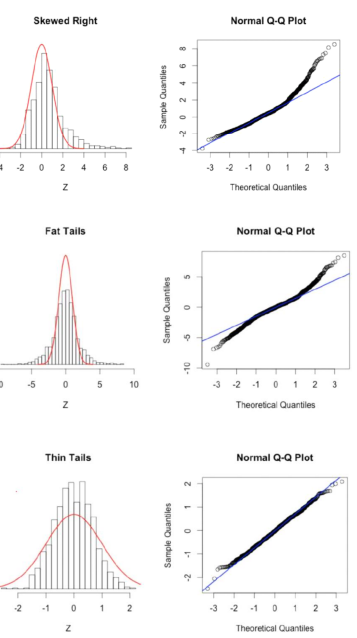



## We Use FunctionTrasformer from sklearn.preprocessing

In [87]:
!pip install scipy

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score,accuracy_score

In [89]:
# Load the dataset with the necessary columns
dataset=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
dataset.sample(5)

,Survived,Age,Fare
762,1,20.0,7.2292
221,0,27.0,13.0000
849,1,NaN,89.1042
389,1,17.0,12.0000
286,1,30.0,9.5000


In [90]:
# Check & Fill the null values
imputer=SimpleImputer(strategy='mean')
# The Simputer will return us and 2d so we need to explictily convert it into dataframe
imputer.set_output(transform="pandas")
dataset=imputer.fit_transform(dataset)

In [91]:
dataset.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [92]:
dataset.sample()

,Survived,Age,Fare
712,1.0,48.0,52.0


In [93]:
# Train test Split the dataset

X_train,X_test,y_train,y_test=train_test_split(dataset.iloc[:,1:3],dataset.iloc[:,0],test_size=0.25,random_state=42)

In [94]:
X_train

,Age,Fare
298,29.699118,30.5000
884,25.000000,7.0500
247,24.000000,14.5000
478,22.000000,7.5208
305,0.920000,151.5500
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


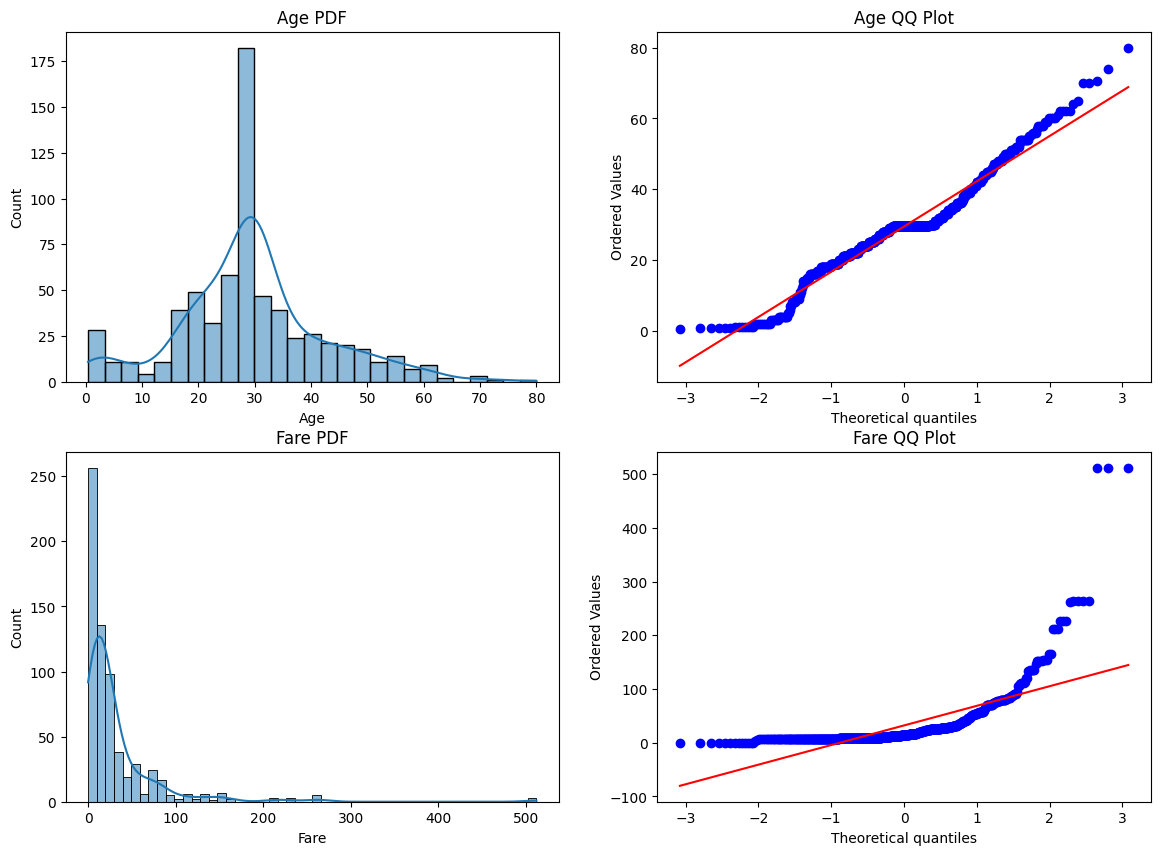

In [95]:
# plot dist plot and qq plot on the present data
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(222)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.subplot(223)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()


In [98]:
# By This we can see that Age is Near to Normal Distribution, where as fare is Right skewed Data
# Lets Train a Model With out any trasformation and check the accuracy. We will be using logistic regression for this classification problem.

pipe=Pipeline([
    ('model',LogisticRegression())
])

pipe.fit(X_train,y_train)
y_predicted=pipe.predict(X_test)
accuracy=accuracy_score(y_test,y_pred=y_predicted)
print('Accuracy Before trasformation:',accuracy)

Accuracy Before trasformation: 0.6636771300448431


In [99]:
# Now Lets apply FunctionTrasformation

transform=FunctionTransformer(func=np.log1p)
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

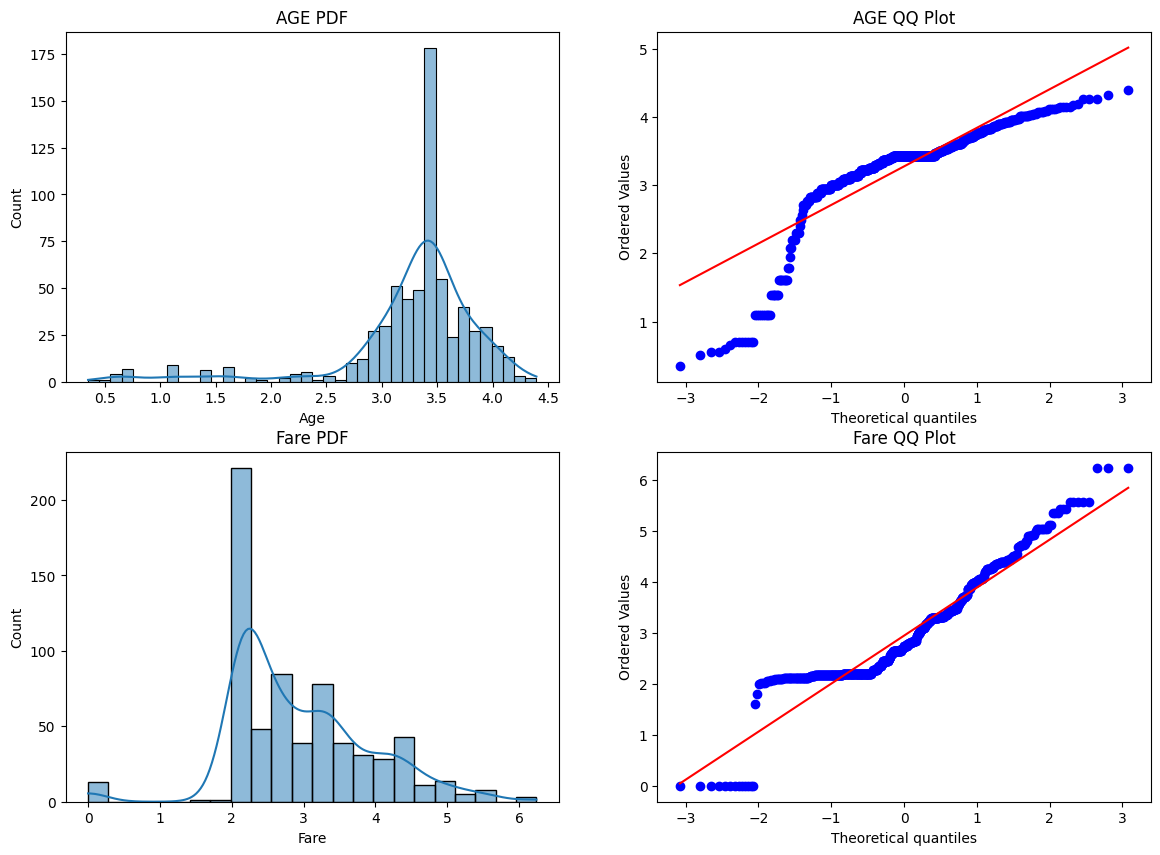

In [108]:
#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

In [116]:
# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


Accuracy after Trasfomation:  0.6816143497757847


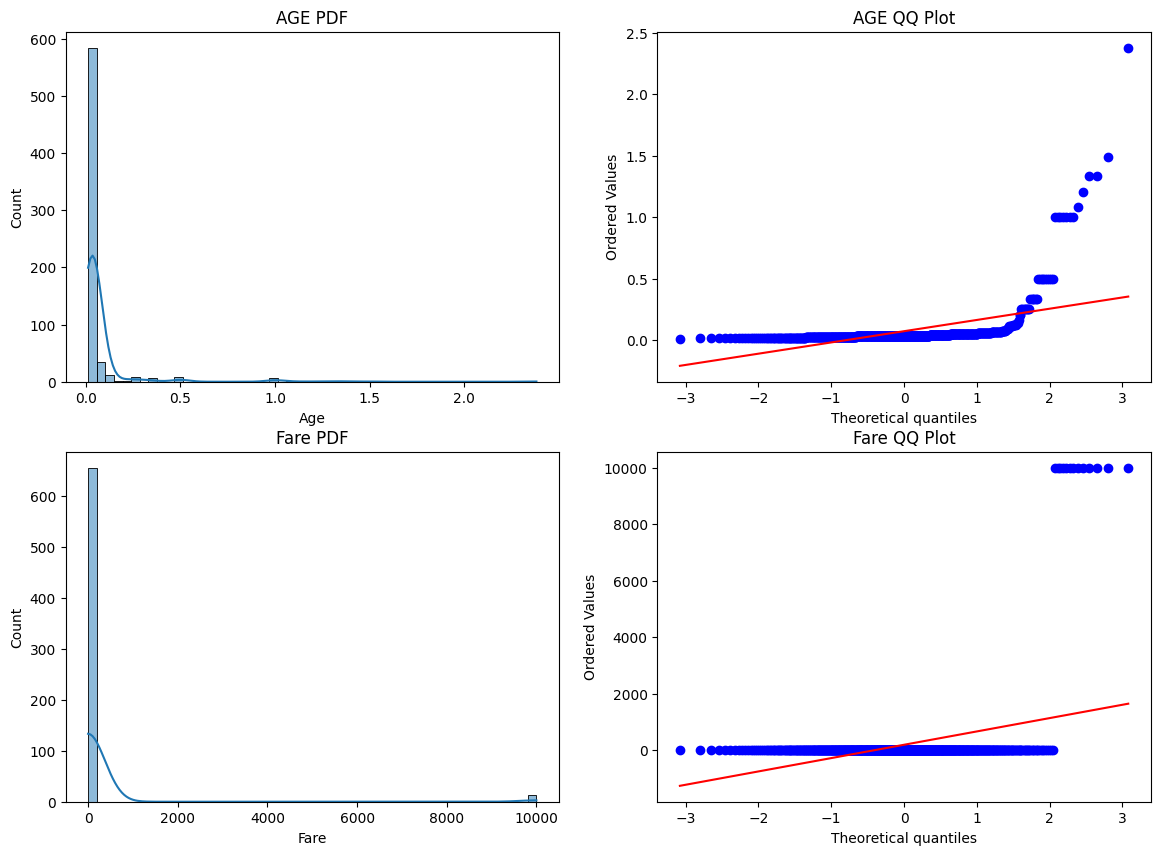

Accuracy after Trasfomation:  0.600896860986547


In [117]:
# Now Lets apply resiprocal

transform=FunctionTransformer(func=lambda x:1/(x+0.0001))
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


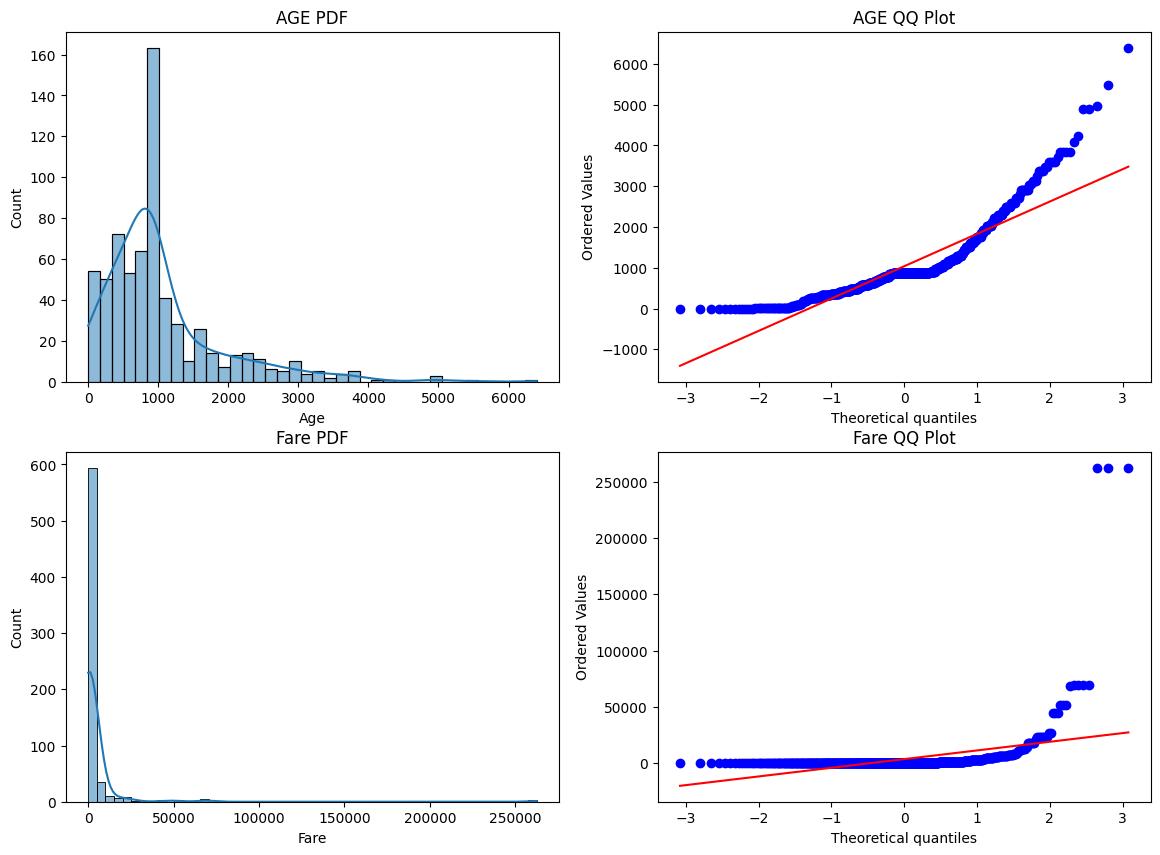

Accuracy after Trasfomation:  0.6278026905829597


In [118]:
# Lets apply x^2

transform=FunctionTransformer(func=lambda x:x**2)
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


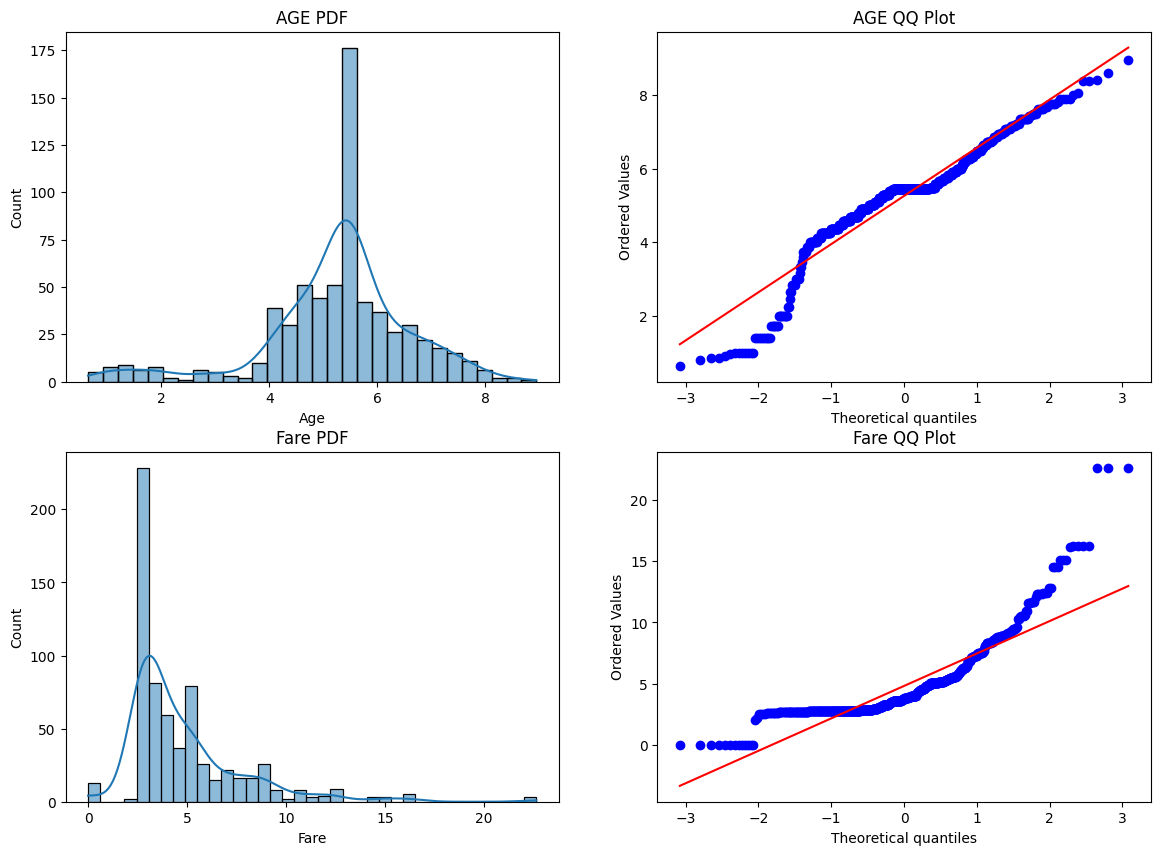

Accuracy after Trasfomation:  0.6816143497757847


In [119]:
# Lets apply sqrt(x)

transform=FunctionTransformer(func=lambda x:x**(1/2))
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)
